In [17]:
import datetime


def date_to_utc(date: datetime.datetime):
    return date.replace(tzinfo=datetime.timezone.utc)


In [18]:
import datetime
from typing import Literal


class TimeseriesDate:
    def __init__(self, date: datetime.datetime, time_unit: Literal['D', 'H', '15M']):
        self.__date = date_to_utc(date)
        self.time_unit: Literal['D', 'H', '15M'] = time_unit

    def get_date(self):
        return self.__date

    def get_next_timeseries_date(self, steps: int) -> 'TimeseriesDate':
        if steps == 0:
            return self

        if self.time_unit == 'D':
            d = self.__date + datetime.timedelta(days=steps)
        elif self.time_unit == 'H':
            d = self.__date + datetime.timedelta(hours=steps)
        elif self.time_unit == '15M':
            d = self.__date + datetime.timedelta(minutes=steps * 15)
        else:
            raise Exception(f'Unknown time time_unit {self.time_unit}')

        return TimeseriesDate(
            date=d,
            time_unit=self.time_unit
        )

    def get_time_unit_seconds(self):
        return 60 * 60 * 24 if self.time_unit == 'D' else 60 * 60 if self.time_unit == 'H' else 60 * 15


In [19]:
import datetime
from typing import Literal, List

import pandas as pd
from dateutil.relativedelta import relativedelta



class TimeseriesInterval(TimeseriesDate):

    def __init__(self, date_from: datetime.datetime, date_to: datetime.datetime, time_unit: Literal['D', 'H', '15M']):
        date_from = date_to_utc(date_from)
        date_to = date_to_utc(date_to)
        super().__init__(date_from, time_unit)
        self.__date_to = date_to

    def get_date_from(self):
        return self.get_date()

    def get_date_to(self):
        return self.__date_to

    @staticmethod
    def create_from_steps(date: TimeseriesDate, steps: int = 0):
        if steps >= 0:
            return TimeseriesInterval(
                date_from=date.get_date(),
                date_to=date.get_next_timeseries_date(steps).get_date(),
                time_unit=date.time_unit
            )
        else:
            return TimeseriesInterval(
                date_from=date.get_next_timeseries_date(steps).get_date(),
                date_to=date.get_date(),
                time_unit=date.time_unit
            )

    def get_intervals(self, batch_size: int = 1):
        res: List[TimeseriesInterval] = []

        for i in range(int(self.get_steps_cnt() / batch_size) + 1):
            iter_date_from = self.get_next_timeseries_date(i * batch_size)
            iter_date_to = self.get_next_timeseries_date((i + 1) * batch_size - 1)

            if iter_date_to.get_date() > self.get_date_to():
                iter_date_to = TimeseriesDate(self.get_date_to(), self.time_unit)

            res.append(TimeseriesInterval(
                date_from=iter_date_from.get_date(),
                date_to=iter_date_to.get_date(),
                time_unit=self.time_unit
            ))

            if iter_date_to.get_date() == self.get_date_to():
                break

        return res

    def get_steps_cnt(self):
        if self.time_unit == 'D':
            time_range = pd.date_range(self.get_date_from(), self.get_date_to(), freq='d')
            cnt = len(time_range)
        elif self.time_unit == 'H':
            time_range = pd.date_range(self.get_date_from(), self.get_date_to(), freq='h')
            cnt = len(time_range)
        elif self.time_unit == '15M':
            time_range = pd.date_range(self.get_date_from(), self.get_date_to(), freq='m')
            cnt = int(len(time_range) / 15)
        else:
            raise Exception(f'Unknown time time_unit {self.time_unit}')

        return cnt

    def get_steps_range(self):
        return range(self.get_steps_cnt())

    def get_months_cnt(self):
        return relativedelta(self.get_date_to(), self.get_date_from()).months

In [20]:
from dataclasses import dataclass


@dataclass
class ModelDef:
    name: str
    ctx: int

    def get_model_id(self):
        return f'{self.name}__{self.ctx}'


In [21]:
import pandas as pd

class PredPricesLoaderBase:

    def __init__(self):
        self.all_models_defs = {}

    def load(self, model_def: ModelDef) -> pd.DataFrame:
        raise Exception('Not implemented')



In [22]:
from typing import List
import pandas as pd

class RealPricesLoaderBase:
    def get_symbols(self) -> List[str]:
        raise Exception('Not implemented')

    def load(self, symbol: str) -> pd.DataFrame:
        raise Exception('Not implemented')

    def df(self) -> pd.DataFrame:
        raise Exception('Not implemented')


In [23]:
from dataclasses import dataclass
import datetime
from typing import List, Optional

import pandas as pd
import numpy as np

@dataclass
class PricesHistItem:
    open: np.ndarray
    close: np.ndarray
    volume: np.ndarray
    buy_volume: np.ndarray
    sell_volume: np.ndarray


class RealPricesProvider:

    def __init__(self, real_prices_loader: RealPricesLoaderBase, filter_symbols: Optional[List[str]] = None):
        self.real_prices_loader = real_prices_loader
        self.filter_symbols = filter_symbols

    def get_prices_df(self, symbol: str):
        return self.real_prices_loader.load(symbol)

    def get_prices_np(self, symbol: str, date: datetime.datetime, hist_cnt: int):
        # Example usage:
        df = self.get_prices_df(symbol)  # or your DataFrame with many symbols
        # If df_raw already has MultiIndex, reset index to get symbol and date as columns:
        if isinstance(df.index, pd.MultiIndex):
            df = df.reset_index()

        # df = self.interpolate_zeros_by_time(df, date_col='date', symbol_col='symbol', value_col='close', freq='D', fill_edges=False)
        # df = self.interpolate_zeros_by_time(df, date_col='date', symbol_col='symbol', value_col='open', freq='D', fill_edges=False)
        # df = self.interpolate_zeros_by_time(df, date_col='date', symbol_col='symbol', value_col='volume', freq='D', fill_edges=False)

        # If you want to restore MultiIndex (symbol, date):
        df = df.set_index(['symbol', 'date']).sort_index()

        if df['close'].eq(0).any():
            raise RuntimeError(f'{symbol} zero value')

        idx = pd.IndexSlice
        n = df.loc[idx[[symbol], :date], :]['close'].tail(hist_cnt).to_numpy().squeeze()

        return n

    def get_volumes_np(self, symbol: str, date: datetime.datetime, hist_cnt: int):
        df  = self.get_prices_df(symbol)
        df = df.set_index(['symbol', 'date'])
        idx = pd.IndexSlice
        n = df.loc[idx[[symbol], :date], :]['volume'].tail(hist_cnt).to_numpy().squeeze()
        return n

    def get_prices_hist_item(self, symbol: str, date: datetime.datetime, hist_cnt: int):
        df  = self.get_prices_df(symbol)
        df = df.set_index(['symbol', 'date'])
        df2 = df.loc[pd.IndexSlice[[symbol], :date], :]
        return PricesHistItem(
            open=df2['open'].tail(hist_cnt).to_numpy().squeeze(),
            close=df2['close'].tail(hist_cnt).to_numpy().squeeze(),
            volume=df2['volume'].tail(hist_cnt).to_numpy().squeeze(),
            buy_volume=df2['buy_volume'].tail(hist_cnt).to_numpy().squeeze(),
            sell_volume=df2['sell_volume'].tail(hist_cnt).to_numpy().squeeze()
        )

    def get_symbols(self) -> List[str]:
        if self.filter_symbols is not None:
            return self.filter_symbols
        return self.real_prices_loader.get_symbols()

    def interpolate_zeros_by_time(self, df, date_col='date', symbol_col='symbol', value_col='close', freq='D', fill_edges=False):

        df = df.copy()

        # Ensure datetime
        df[date_col] = pd.to_datetime(df[date_col], utc=True, errors='coerce')

        # Ensure the value column is numeric (this handles pd.NA!)
        df[value_col] = pd.to_numeric(df[value_col], errors='coerce')

        results = []
        for symbol, sub in df.groupby(symbol_col, sort=True):

            sub = sub.sort_values(date_col)

            # Replace zeros with NaN AFTER converting to numeric
            sub[value_col] = sub[value_col].replace(0, np.nan)

            # Build full date range
            start, end = sub[date_col].min(), sub[date_col].max()
            full_index = pd.date_range(start, end, freq=freq, tz=start.tz)

            # Create a numeric Series indexed by date
            s = sub.set_index(date_col)[value_col]

            # Reindex → interpolate → back to original dates
            s_full = s.reindex(full_index)

            s_interp = s_full.interpolate(method='timeseries', limit_area='inside')

            if fill_edges:
                s_interp = s_interp.fillna(method='bfill').fillna(method='ffill')

            # return only original timestamps
            s_final = s_interp.reindex(s.index)

            # Reattach to sub
            sub[value_col] = s_final.values
            results.append(sub)

        df_out = pd.concat(results).sort_values([symbol_col, date_col])

        return df_out


In [24]:
import os
from typing import List
import pandas as pd


class RealPricesLoaderCSV(RealPricesLoaderBase):

    __cache = {}

    def __init__(self, prices_csv_file: str):
        self.__df = pd.read_csv(prices_csv_file)
        self.__df['date'] = pd.to_datetime(self.__df['date'], utc=True, format='%Y-%m-%d %H:%M:%S')
        # self.__df = self.__df[['date', 'symbol', 'open', 'close', 'volume', 'buy_volume', 'sell_volume']]
        self.symbols: List[str] = self.__df['symbol'].unique().tolist()
        self.symbols.sort()

    def df(self) -> pd.DataFrame:
        return self.__df

    def get_symbols(self) -> List[str]:
        return self.symbols

    def load(self, symbol: str) -> pd.DataFrame:
        if symbol in RealPricesLoaderCSV.__cache:
            return RealPricesLoaderCSV.__cache[symbol]

        df = self.__df[self.__df['symbol'] == symbol]

        if symbol not in RealPricesLoaderCSV.__cache:
            RealPricesLoaderCSV.__cache[symbol] = {}
        RealPricesLoaderCSV.__cache[symbol] = df

        return df


In [25]:
import datetime
import pandas as pd

class PredPricesProvider:

    def __init__(
        self,
        predicted_prices_loader: PredPricesLoaderBase
    ):
        self.predicted_prices_loader = predicted_prices_loader

    def get_prices_np(self, model_def: ModelDef, symbol: str, date: datetime.datetime, hist_cnt: int):
        df  = self.predicted_prices_loader.load(model_def)
        idx = pd.IndexSlice
        n = df.loc[idx[[symbol], :date], :]['close'].tail(hist_cnt).to_numpy().squeeze()
        return n

    def get_models_defs(self):
        return self.predicted_prices_loader.all_models_defs


In [36]:
import os
from typing import List, Optional
import pandas as pd


class PredPricesLoaderCSV(PredPricesLoaderBase):

    def __init__(
        self,
        prices_base_dir: str,
        filter_models: Optional[List[str]] = None
    ):
        super().__init__()
        self.prices_base_dir = prices_base_dir
        self.__cache = {}

        csv_files_path = f'{self.prices_base_dir}'
        csv_files = [f for f in os.listdir(csv_files_path) if os.path.isfile(os.path.join(csv_files_path, f))]

        for f in csv_files:
            arr = f.removesuffix('.csv').split('__')
            model_def = ModelDef(
                name=arr[0],
                ctx=int(arr[1].split('_')[1]),
            )

            if filter_models is not None and model_def.name not in filter_models:
                continue

            model_id = model_def.get_model_id()

            if model_id not in self.all_models_defs:
                self.all_models_defs[model_id] = model_def

            pred_df = pd.read_csv(os.path.join(csv_files_path, f))
            pred_df['date'] = pd.to_datetime(pred_df['date'], format='%Y-%m-%d %H:%M:%S', utc=True)
            pred_df = pred_df.set_index(['symbol', 'date'])

            self.__cache[model_id] = pred_df

    def load(self, model_def: ModelDef) -> pd.DataFrame:
        return self.__cache[model_def.get_model_id()]


class PredPricesLoaderCSV2(PredPricesLoaderBase):

    def __init__(
            self,
            prices_file: str,
            filter_models: Optional[List[str]] = None
    ):
        super().__init__()
        self.__cache = {}

        main_df = pd.read_csv(prices_file)

        for (model, ctx_len), pred_df in main_df.groupby(['model', 'ctx']):
            model_def = ModelDef(
                name=model,
                ctx=ctx_len,
            )

            if filter_models is not None and model_def.name not in filter_models:
                continue

            model_id = model_def.get_model_id()

            if model_id not in self.all_models_defs:
                self.all_models_defs[model_id] = model_def

            pred_df['date'] = pd.to_datetime(pred_df['date'], format='%Y-%m-%d %H:%M:%S', utc=True)
            pred_df = pred_df.set_index(['symbol', 'date'])
            pred_df.sort_index(ascending=True, inplace=True)
            pred_df.rename(columns={'predicted': 'close'}, inplace=True)
            pred_df.drop(columns=['model', 'ctx'], inplace=True)

            self.__cache[model_id] = pred_df

    def load(self, model_def: ModelDef) -> pd.DataFrame:
        return self.__cache[model_def.get_model_id()]


In [37]:
from dataclasses import dataclass

import numpy as np


@dataclass
class ModelData:
    state: np.ndarray
    open_price: np.ndarray
    close_price: np.ndarray
    symbols_cnt: int
    days_cnt: int

In [38]:
import torch
from torch.utils.data import Dataset

class DatasetSequential(Dataset):
    """
    Dataset for supervised training of the trading agent using sequential data.
    Each sample is a sequence of features up to timeseries t, with label y at timeseries t.
    """

    def __init__(self, model_data, seq_len: int = 14):
        """
        Args:
            model_data: ModelData object (contains state, flips, open/close prices).
            seq_len: Length of the sequence window for input.
        """
        self.state = torch.tensor(model_data.state, dtype=torch.float32)  # shape: (days_cnt, feature_dim)
        open_price = torch.tensor(model_data.open_price, dtype=torch.float32)
        close_price = torch.tensor(model_data.close_price, dtype=torch.float32)
        self.target = (close_price < open_price).long() # 0=long, 1=short

        self.seq_len = seq_len
        self.days_cnt = model_data.days_cnt

    def __len__(self):
        return self.days_cnt - self.seq_len

    def __getitem__(self, idx):
        # sequence from idx → idx+seq_len
        x_seq = self.state[idx : idx + self.seq_len]  # (seq_len, feature_dim) and starting from index ending at index + sequence length

        # target action = long/short at the last day of the sequence
        last_idx = idx + self.seq_len
        y = self.target[last_idx]

        return (
            x_seq,  # (seq_len, feature_dim)
            y
        )

class DatasetSequentialAugmented(DatasetSequential):
    def __init__(self, model_data, seq_len: int = 14):
        super().__init__(model_data, seq_len)
        self.aug_window = seq_len * 2

    def __len__(self):
        return self.days_cnt - self.aug_window

    def __getitem__(self, idx):
        # Choose window (larger if augmentation enabled)
        window = self.state[idx : idx + self.aug_window]

        # Ensure last timestep is always included
        last_idx_in_window = self.aug_window - 1
        # Randomly choose seq_len-1 indices from earlier part
        rand_idx = torch.randperm(self.aug_window - 1)[: self.seq_len - 1]
        selected_idx = torch.cat([
            torch.sort(rand_idx)[0],
            torch.tensor([last_idx_in_window])
        ])
        x_seq = window[selected_idx]

        last_idx = idx + self.aug_window
        y = self.target[last_idx]

        return x_seq, y


In [39]:



class DatasetFlat(DatasetSequential):
    def __getitem__(self, idx):
        x_seq, y = super().__getitem__(idx)

        return x_seq.flatten(), y

class DatasetFlatAugmented(DatasetSequentialAugmented):
    def __getitem__(self, idx):
        x_seq, y = super().__getitem__(idx)

        return x_seq.flatten(), y


In [95]:
import torch.nn as nn

class Compound_LSTM(nn.Module):
    def __init__(self, batch_size, input_features, batch_first, out_size, device, dtype, hidden_size):
        super().__init__()
        self.seq_amnt = batch_size
        self.feature_amnt = input_features
        self.h1_s = hidden_size
        self.h2_s = hidden_size
        self.h3_s = hidden_size

        self.lstm1 = nn.LSTM(self.feature_amnt, self.h1_s, batch_first = batch_first, device = device, dtype = dtype)
        self.lstm2 = nn.LSTM(self.h1_s, self.h2_s, batch_first = batch_first, device = device, dtype = dtype)
        self.lstm3 = nn.LSTM(self.h2_s, self.h3_s, batch_first = batch_first, device = device, dtype = dtype)

        self.fc = nn.Linear(self.h3_s, out_size, device = device)

    def forward(self, seq_batch):
        out1, hc = self.lstm1(seq_batch)
        
        out2, hc = self.lstm2(out1)
        
        out3, hc = self.lstm3(out2)
        out3 = self.fc(out3[:, -1, :]) # since we need a single last output

        return out3





In [177]:
from dataclasses import dataclass
import sys
from typing import List

import numpy as np
import torch

@dataclass
class AgentConfig:
    #model parameters
    device: str = "cpu"
    learning_rate: float = 0.0003
    batch_size: int = 15
    generation: int = 75
    seq_len: int = 20
    hidden_size: int = 160
    
    #test and train parameters
    dtype = torch.float32
    batch_first: bool = True
    out_size: int = 1
    test_step: int = 7
    freq_rate_train: int = 10
    freq_rate_test: int = 10

class Agent:
    def __init__(self, config: AgentConfig, real_prices_provider: RealPricesProvider, pred_prices_provider: PredPricesProvider, symbols_amnt):
        self.config = config
        self.real_prices_provider = real_prices_provider
        self.pred_prices_provider = pred_prices_provider

        # batch_size, input_features, batch_first, out_size, device, dtype, hidden_size, layer_amnt, dropout
        self.model = Compound_LSTM(self.config.batch_size, symbols_amnt, self.config.batch_first,
                                   self.config.out_size, self.config.device, self.config.dtype, self.config.hidden_size)


    def train(self, interval: TimeseriesInterval, symbols: List[str]):
        model = self.model
        optimizer = torch.optim.Adam(model.parameters(), lr = self.config.learning_rate)
        criterion = torch.nn.BCEWithLogitsLoss()
        model.train()

        dataset = self.prepare_dataset(symbols, interval, augmentation = True)

        episode = 0
        error_rtt = []
        batch_rtt = []
        total_batches = 0
        while episode < self.config.generation:
            idx = 0
            stop = False
            
            
            episode_error = 0 #error per episode
            num_batches = 0 #number of batches per episode
            while not stop:
                batch_x = []
                batch_y = []

                for i in range(self.config.batch_size):
                    start_pos = idx * self.config.batch_size + i
                    if start_pos >= len(dataset):
                        stop = True
                        break

                    x_seq, y = dataset[start_pos]  #returns a tensor x_seq of size (seq_number, feature_amnt) and a tensor y with real values
                    if x_seq.size(0) < self.config.seq_len: #since we have less than needed number of records in a sequence
                        stop = True
                        break
                    
                    batch_x.append(x_seq)
                    batch_y.append(y)

                if len(batch_x) == 0:
                    break

                batch_x = torch.stack(batch_x, dim = 0)  #shape: (batch, seq_len, feature_dim) basically stack up one after another tables of size (seq_len, feature_dim)

                batch_y = torch.tensor(batch_y, dtype = self.config.dtype)
                batch_y = batch_y.unsqueeze(1)

                batch_x = batch_x.to(self.config.device)
                batch_y = batch_y.to(self.config.device)

                optimizer.zero_grad()
                outputs = model(batch_x) #call model, not forward directly
                loss = criterion(outputs, batch_y) #compute loss
                episode_error += loss.item()
                loss.backward()
                optimizer.step()

                num_batches += 1
                idx += 1
            total_batches += num_batches
            
            avg_loss = episode_error / num_batches if num_batches > 0 else float('nan')
            error_rtt.append(avg_loss)
            batch_rtt.append(total_batches)
            
            episode += 1

        self.test(interval, symbols, True)
        return error_rtt, batch_rtt






    def test(self, interval: TimeseriesInterval, symbols: List[str], train = False):
        TP, TN, FP, FN = 0, 0, 0, 0
        criterion = torch.nn.BCEWithLogitsLoss()
        error_sequence = []
        frequen_rate = self.config.freq_rate_test

        model = self.model
        model.eval()
        dataset = self.prepare_dataset(symbols, interval, augmentation = False)
        tstp_amnt = interval.get_steps_cnt()
        seq_len = self.config.seq_len
        device = self.config.device
        
        seq_ind = 0 #represents sequence_window index as well as number of predictions
        with torch.no_grad():
            while True:
                if(seq_ind + seq_len >= tstp_amnt): break
                x_seq, y = dataset[seq_ind]

                x_seq = x_seq.to(device).float()
                x_seq = x_seq.to(device).unsqueeze(0)

                pred_y = model(x_seq) #tensor of 1x1
                real_y = y.to(device).float().view(1, 1) # so now it also has size of 1x1
                
                if((seq_ind + 1) % frequen_rate == 0):
                    error = criterion(pred_y, real_y)
                    error_sequence.append(error.item())
                    
                
                pred_y = torch.sigmoid(pred_y)
                pred_y = pred_y.item() #because pred_y previosuly was a tensor

                pred_y = 1 if pred_y > 0.5 else 0 #now it's 0 or 1 depending on its value



                if(pred_y == real_y.item()):
                    if(real_y.item()):
                        TP += 1
                    else:
                        TN += 1
                else:
                    if(real_y.item()):
                        FN += 1
                    else:
                        FP += 1

                precision = TP / (TP + FP) if (TP + FP) > 0 else 0
                recall = TP / (TP + FN) if (TP + FN) > 0 else 0
                f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

                seq_ind += 1

        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        f1_score *= 100
        precision *= 100
        recall *= 100
        if(not train):
            print("Test scores:")
            print(f"F1_score: {f1_score:.2f}")
            print(f"Recall: {recall:.2f}")
            print(f"Precision: {precision:.2f}")
            print("\n")
        else:
            print("Train scores:\n")
            print(f"F1_score: {f1_score:.2f}")
            print(f"Recall: {recall:.2f}")
            print(f"Precision: {precision:.2f}")
            print("\n")
            
        return error_sequence, frequen_rate



    def prepare_dataset(self, symbols: List[str], timeseries_interval: TimeseriesInterval, augmentation=False):
        model_data = self.__get_model_state(
            timeseries_interval,
            symbols=symbols
        )

        # choose between sequential and flat representation
        if augmentation:
            # dataset = DatasetFlatAugmented(model_data, seq_len=self.config.seq_len)
            dataset = DatasetSequentialAugmented(model_data, seq_len=self.config.seq_len)

        else:
            # dataset = DatasetFlat(model_data, seq_len=self.config.seq_len)
            dataset = DatasetSequential(model_data, seq_len=self.config.seq_len)

        return dataset

    # DO NOT MODIFY!
    def __get_model_state(self, timeseries_interval: TimeseriesInterval, symbols: List[str], hist_items_cnt: int = 1):
        symbols_cnt = len(symbols)
        timeseries_cnt = timeseries_interval.get_steps_cnt()
        models_defs = self.pred_prices_provider.get_models_defs()

        seq_features = []

        open_price = np.ndarray((symbols_cnt, timeseries_cnt), dtype=np.float32)
        close_price = np.ndarray((symbols_cnt, timeseries_cnt), dtype=np.float32)

        for symbol_idx, symbol in enumerate(symbols):
            real_prices_hist = self.real_prices_provider.get_prices_np(symbol=symbol, date=timeseries_interval.get_date_to(), hist_cnt=timeseries_cnt + 2)
            real_return_hist = (real_prices_hist[1:] - real_prices_hist[:-1]) / real_prices_hist[:-1]

            for i in range(timeseries_cnt):
                real_return = [real_return_hist[i]]
                close_price[symbol_idx][i] = real_prices_hist[i + 2]
                open_price[symbol_idx][i] = real_prices_hist[i + 1]

                # --- Predictions ---
                date_to = timeseries_interval.get_next_timeseries_date(i).get_date()
                pred_features = []
                for model_idx, model_id in enumerate(models_defs):
                    pred_prices_hist = self.pred_prices_provider.get_prices_np(models_defs[model_id], symbol, date=date_to, hist_cnt=hist_items_cnt + 1)
                    pred_return_hist = (pred_prices_hist[1:] - pred_prices_hist[:-1]) / pred_prices_hist[:-1]
                    pred_features.extend(pred_return_hist.tolist())

                # Combine features: [real_return_hist + all_pred_returns]
                day_features = np.concatenate([real_return, pred_features])
                seq_features.append(day_features)

        seq_features = np.array(seq_features, dtype=np.float32)  # shape: (days_cnt, feature_dim)

        return ModelData(
            days_cnt=timeseries_cnt,
            symbols_cnt=symbols_cnt,
            state=seq_features,
            open_price=open_price.flatten(),
            close_price=close_price.flatten(),
        )


In [178]:
import datetime
import os
import sys


def utc_datetime(year: int, month: int, day: int):
    return datetime.datetime(year, month, day, tzinfo=datetime.timezone.utc)

if __name__ == '__main__':
    # AGENT_SYMBOLS = [                 #better to refer to them as features since symbols is harder to understand, maybe cryptocurrencies
    #     'BINANCE_SPOT_DOT_USDT',
    #     'BINANCE_SPOT_SOL_USDT',
    #     'BINANCE_SPOT_BNB_USDT',
    #     'BINANCE_SPOT_LINK_USDT',
    #     'BINANCE_SPOT_ADA_USDT',
    #     'BINANCE_SPOT_AVAX_USDT',
    #     'BINANCE_SPOT_LTC_USDT',
    #     'BINANCE_SPOT_XRP_USDT',
    #     'BINANCE_SPOT_BTC_USDT',
    #     'BINANCE_SPOT_ICP_USDT',
    #     'BINANCE_SPOT_TRX_USDT',
    #     'BINANCE_SPOT_SHIB_USDT',
    #     'BINANCE_SPOT_ETH_USDT',
    #     'BINANCE_SPOT_DOGE_USDT',
    # ]

    AGENT_SYMBOLS = [
        'BINANCE_SPOT_DOT_USDT',
    ]

    ACTION_LONG = 0
    ACTION_SHORT = 1
    MODEL_ACTIONS = [ACTION_LONG, ACTION_SHORT]

    AGENT_PRED_CSV_FILE = os.getcwd() + '/data/predictions.csv'
    AGENT_REAL_DAILY_PRICES_PROVIDER = RealPricesProvider(
        real_prices_loader=RealPricesLoaderCSV(
            prices_csv_file=os.getcwd() + '/data/prices_updated.csv'
        ),
        filter_symbols=AGENT_SYMBOLS
    )

    AGENT_PRED_MODELS = [
        'moirai_base',
        'moirai_large',
        'chronos',
        'tirex',
        'sundial'
    ]

    AGENT_PRED_PRICES_PROVIDER = PredPricesProvider(
        predicted_prices_loader=PredPricesLoaderCSV2(
            prices_file=AGENT_PRED_CSV_FILE,
            filter_models=AGENT_PRED_MODELS,
        )
    )

    AGENT_TRAIN_INTERVAL = TimeseriesInterval(
        date_from=utc_datetime(2023, 10, 1),
        date_to=utc_datetime(2025, 1, 1),
        time_unit='D'
    )

    AGENT_TEST_INTERVAL = TimeseriesInterval(
        date_from=utc_datetime(2025, 1, 1),
        date_to=utc_datetime(2025, 10, 31),
        time_unit='D'
    )

    config = AgentConfig()

    agent = Agent(
        config=config,
        real_prices_provider=AGENT_REAL_DAILY_PRICES_PROVIDER,
        pred_prices_provider=AGENT_PRED_PRICES_PROVIDER,
        symbols_amnt = len(AGENT_SYMBOLS) + len(AGENT_PRED_MODELS) * 3
    )


In [179]:
for symbol in AGENT_SYMBOLS:
    print(symbol)
    error_rtt_train, batch_rtt = agent.train(interval = AGENT_TRAIN_INTERVAL, symbols = [symbol])
    error_rtt_test, freq_rate_test = agent.test(interval = AGENT_TEST_INTERVAL, symbols = [symbol])


BINANCE_SPOT_DOT_USDT
Train scores:

F1_score: 63.12
Recall: 73.39
Precision: 55.36


Test scores:
F1_score: 54.09
Recall: 59.31
Precision: 49.71




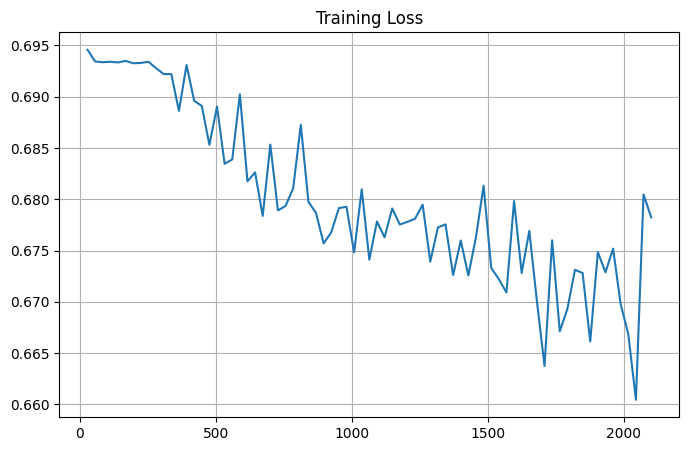

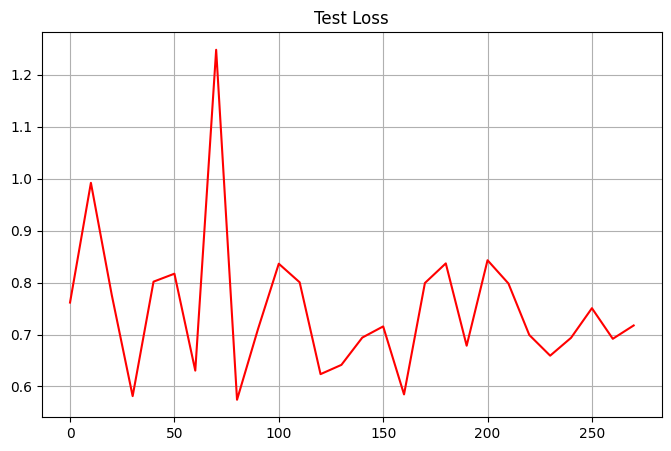

In [180]:
import matplotlib.pyplot as plt
timeline_test = [ts * freq_rate_test for ts in range(len(error_rtt_test))]
timeline_train = [ts for ts in batch_rtt]

fig1 = plt.figure(figsize=(8, 5))
plt.plot(timeline_train, error_rtt_train)
plt.title('Training Loss')
plt.grid()
# fig1.show()  # not needed if you call plt.show() later

fig2 = plt.figure(figsize=(8, 5))
plt.plot(timeline_test, error_rtt_test, color='red')
plt.title('Test Loss')
plt.grid()

plt.show()
